In [1]:
#Importing necessary libraries and setting up the environment for the Food Workflow Agent
from langchain_groq import ChatGroq
import os
from typing import TypedDict, List, Literal
from pydantic import BaseModel
from pydantic import ConfigDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
import requests
import json
import pandas as pd

# setting the API key for Groq
os.environ["GROQ_API_KEY"] = "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"

# creating the LLM
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0
)

In [2]:
# Fetching a random recipe from TheMealDB API
url = "https://www.themealdb.com/api/json/v1/1/random.php"

# Making a GET request to the API and parsing the response as JSON
response = requests.get(url)
data = response.json()

# Extracting the first meal from the response
meal = data["meals"][0]

# Extracting the recipe title, instructions, and ingredients with their measurements
title = meal["strMeal"]
instructions = meal["strInstructions"]

ingredients = []

# TheMealDB API provides up to 20 ingredients and their corresponding measurements in the format strIngredient1, strMeasure1, strIngredient2, strMeasure2, etc. 
for i in range(1, 21):
    ingredient = meal["strIngredient" + str(i)]
    measure = meal["strMeasure" + str(i)]

    if ingredient and ingredient.strip() != "":
        ingredients.append((measure + " " + ingredient).strip())

# Constructing the recipe text by combining the title, ingredients, and instructions
recipe_text = "Recipe Title: " + title + "\n\n"

recipe_text += "Ingredients:\n"
for item in ingredients:
    recipe_text += "- " + item + "\n"

recipe_text += "\nInstructions:\n" + instructions

print("Loaded recipe:", title)
print("\nRecipe preview:\n")
print(recipe_text[:1000])

Loaded recipe: Oatmeal pancakes

Recipe preview:

Recipe Title: Oatmeal pancakes

Ingredients:
- 1 medium Egg
- 80 ml  Milk
- 1 tablespoon Sugar
- 1 tsp Baking Powder
- Pinch Salt
- 1 dash Vanilla Extract
- 150g Ground Oats
- 150g Butter
- 1 tablespoon Sugar Syrup
- 3 Strawberries

Instructions:
Place all the ingredients in the glass and beat.
Let the mixture stand for 10 minutes.
Grease a hot frying pan with a little butter and pour a little of the mixture.
When it starts to bubble on the surface, turn over with a spatula. Cook over medium-low heat so that they do not burn.
Finally, add the caramel and strawberries.


In [3]:
# Output of Node 1: Food ingredients analysis
class FoodAnalysis(BaseModel):
    recipe_name: str
    ingredients: List[str]
    main_actions: List[str]

# Output of Node 2: critique of the itinerary
class ItineraryCritique(BaseModel):
    strengths: List[str]            # what the itinerary does well 
    weaknesses: List[str]           # what the itinerary does poorly
    missing_steps: List[str]        # any important steps that are missing from the itinerary



# 2) AgentState — the shared notebook (Food Workflow)

class AgentState(TypedDict, total=False):
    recipe_text: str             # the full recipe text including title, ingredients, and instructions
    analysis: FoodAnalysis       # the output of the food ingredients analysis node
    itinerary: str               # the generated itinerary for cooking the recipe
    critique: ItineraryCritique  # the critique of the generated itinerary

In [4]:
# Prompt for Node 1: Food Analyzer
FoodAnalysis_prompt = """
You are a helpful cooking assistant.

From the recipe text below, extract:
1) recipe_name
2) ingredients (a list)
3) main_actions (a list of 6 to 12 short actions)

Rules for main_actions:
- Write actions as short verbs (example: "Soak the beans", "Mix spices", "Fry until golden")
- Include prep actions if needed (wash, chop, soak, mix)
- Keep it simple and beginner friendly

Return ONLY JSON.

Recipe text:
{recipe_text}
"""

# Prompt for Node 3: Itinerary Critique
cooking_itinerary_prompt = """
You are a culinary instructor.

Food request: {food_request}
Difficulty: {difficulty}
Servings: {servings}

Known dish name: {foodname}
Prep time target: {preptime}
Essential ingredients: {ingredients}

### Steps
1. Create a step-by-step cooking itinerary from prep to serving.
2. Use numbered steps (1., 2., 3., ...).
3. Include measurable details when relevant (time, heat level/temperature, quantities).
4. Include prep → cook → serve flow.

### Rules
- Do NOT output JSON.
- Do NOT add extra commentary.
- Keep it realistic for the given difficulty.
- Do NOT assume ingredients not listed.
- Avoid “until done”; use times or observable cues.

Return ONLY the itinerary text.
"""

Itinerary_prompt = """
You are a cooking assistant helping beginners.

Using the recipe analysis below, create clear step-by-step cooking instructions.

Rules:
- Use simple language
- Each step should be short
- Assume the user is a beginner
- Use numbered steps

Recipe analysis:
{analysis}
"""

Critique_prompt = """
You are checking recipe instructions for quality.

You will be given:
1) the recipe analysis (ingredients + main actions)
2) the generated instructions

Check for:
- Ingredients mismatch: instructions mention ingredients not in the analysis
- Made up details: servings, cooking time, temperatures, quantities that were not given
- Clarity: steps should be short and beginner friendly

Return JSON with:
- strengths (list)
- weaknesses (list)
- missing_steps (list)

Recipe analysis:
{analysis}

Generated instructions:
{itinerary}
"""

Repair_prompt = """
Return JSON only.

Return exactly this JSON format:
{{
  "steps": ["step 1", "step 2", "step 3"]
}}

Rules:
- Only return the JSON object with the key "steps"
- "steps" must be a list of short strings
- Do NOT add any other keys
- Do NOT add servings, time, temperature, or quantities
- Only use ingredients from the analysis

Recipe analysis:
{analysis}

Critique:
{critique}

Old instructions:
{itinerary}
"""



In [5]:
# Node 1: Food Analyzer
def analyze_food(state: AgentState):

    recipe_text = state["recipe_text"]     # input: recipe text (title, ingredients, instructions)

    # Using the LLM with structured output to extract the recipe name, ingredients, and main actions from the recipe text
    structured_llm = llm.with_structured_output( 
        FoodAnalysis,
        method="json_mode"
    )
    # Sending the prompt to the LLM and getting the structured output
    prompt = FoodAnalysis_prompt.format(
        recipe_text=recipe_text
    )

    result = structured_llm.invoke(prompt)

    return {"analysis": result}



# Node 2: Cooking Itinerary Generator
# This node takes the analysis from Node 1 and generates a step-by-step cooking itinerary for the recipe.
def generate_itinerary(state: AgentState):

    analysis = state["analysis"]

    prompt = Itinerary_prompt.format(
        analysis=analysis
    )

    result = llm.invoke(prompt)
    return {"itinerary": result.content}


# Node 3: Itinerary Critique
# This node takes the analysis from Node 1 and the generated itinerary from Node 2, and produces a critique of the itinerary based on the analysis.
def critique_itinerary(state: AgentState):

    analysis = state["analysis"]
    itinerary = state["itinerary"]

    structured_llm = llm.with_structured_output(
        ItineraryCritique,
        method="json_mode"
    )

    prompt = Critique_prompt.format(
        analysis=analysis,
        itinerary=itinerary
    )

    result = structured_llm.invoke(prompt)

    return {"critique": result}
# Node 4: Itinerary Repair
# This node takes the analysis from Node 1, the generated itinerary from Node 2, and the critique from Node 3, and produces a repaired itinerary that addresses the issues identified in the critique while still following the analysis.
def repair_itinerary(state: AgentState):

    analysis = state["analysis"]
    itinerary = state["itinerary"]
    critique = state["critique"]

    structured_llm = llm.with_structured_output(
        RecipeSteps,
        method="json_mode"
    )

    prompt = Repair_prompt.format(
        analysis=analysis,
        critique=critique,
        itinerary=itinerary
    )

    result = structured_llm.invoke(prompt)

    return {"itinerary": result}


In [6]:
# Doing a quick test of Node 1: Food Analyzer just to see the output format and make sure the structured output is working correctly
test_state = {"recipe_text": recipe_text}
out = analyze_food(test_state)
out["analysis"]

FoodAnalysis(recipe_name='Oatmeal pancakes', ingredients=['1 medium Egg', '80 ml  Milk', '1 tablespoon Sugar', '1 tsp Baking Powder', 'Pinch Salt', '1 dash Vanilla Extract', '150g Ground Oats', '150g Butter', '1 tablespoon Sugar Syrup', '3 Strawberries'], main_actions=['Beat the ingredients', 'Let the mixture stand', 'Grease the frying pan', 'Pour the mixture', 'Turn over the pancake', 'Cook over medium-low heat', 'Add caramel', 'Add strawberries'])

In [7]:
# Setting up the StateGraph for the Food Workflow Agent, adding the nodes and edges according to the defined workflow, and compiling the graph into an executable application.
graph = StateGraph(AgentState)

graph.add_node("analyze_food", analyze_food)
graph.add_node("generate_itinerary", generate_itinerary)
graph.add_node("critique_itinerary", critique_itinerary)
graph.add_node("repair_itinerary", repair_itinerary)

graph.add_edge(START, "analyze_food")
graph.add_edge("analyze_food", "generate_itinerary")
graph.add_edge("generate_itinerary", "critique_itinerary")
graph.add_edge("critique_itinerary", "repair_itinerary")
graph.add_edge("repair_itinerary", END)

app = graph.compile()

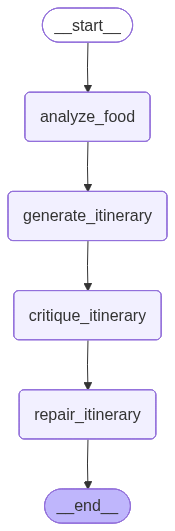

In [8]:
# Visualizing the graph structure of the Food Workflow Agent using Mermaid syntax and displaying it as an image in the notebook.
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
# Running the Food Workflow Agent application with the initial state containing the recipe text, and printing the final output itinerary after going through all the nodes in the workflow.
class RecipeSteps(BaseModel):
    model_config = ConfigDict(extra="forbid")
    steps: List[str]

In [10]:
result = app.invoke({
    "recipe_text": recipe_text
})

print(result["itinerary"].steps)

['Beat the ingredients', 'Let the mixture stand', 'Grease the frying pan', 'Pour the mixture', 'Turn over the pancake', 'Cook over medium-low heat']


In [11]:
# Fetching a random recipe from TheMealDB API
url = "https://www.themealdb.com/api/json/v1/1/random.php"

# Making a GET request to the API and parsing the response as JSON
def get_one_recipe_text():
    data = requests.get(url).json()
    meal = data["meals"][0]

    title = meal["strMeal"]
    instructions = meal["strInstructions"]

    # Extracting the ingredients and their measurements from the API response, and constructing a formatted recipe text that includes the title, ingredients, and instructions.
    ingredients = []
    for i in range(1, 21):
        ing = meal["strIngredient" + str(i)]
        meas = meal["strMeasure" + str(i)]
        if ing and ing.strip() != "":
            ingredients.append((meas + " " + ing).strip())

    recipe_text = "Recipe Title: " + title + "\n\nIngredients:\n"
    for item in ingredients:
        recipe_text += "- " + item + "\n"
    recipe_text += "\nInstructions:\n" + instructions

    return title, recipe_text

In [12]:
# Running multiple tests of the Food Workflow Agent with different random recipes, and collecting the results (recipe title, number of steps in the generated itinerary, and whether it was successful or not) in a list for analysis.
results = []

for i in range(10):
    title, text = get_one_recipe_text()

    try:
        out = app.invoke({"recipe_text": text})
        steps = out["itinerary"].steps

        results.append({
            "title": title,
            "num_steps": len(steps),
            "ok": True
        })

        print(i+1, "OK:", title, "| steps:", len(steps))

    except Exception as e:
        results.append({
            "title": title,
            "num_steps": 0,
            "ok": False
        })

        print(i+1, "FAIL:", title, "|", type(e).__name__)

1 OK: Crock Pot Chicken Baked Tacos | steps: 15
2 OK: Jam Roly-Poly | steps: 12
3 OK: Tourtiere | steps: 14
4 OK: Sea bass with sizzled ginger, chilli & spring onions | steps: 12
5 OK: Ezme | steps: 10
6 OK: Challah | steps: 11
7 OK: Noodle bowl salad | steps: 9
8 OK: Lamb Rogan josh | steps: 12
9 FAIL: Toad In The Hole | BadRequestError
10 OK: Mamoul (Eid biscuits) | steps: 12


In [13]:
# Analyzing the results of the tests by counting how many were successful (ok) out of the total number of tests conducted.
ok_count = 0
for r in results:
    if r["ok"]:
        ok_count += 1

print("\nSuccess:", ok_count, "/ 10")


Success: 9 / 10


In [15]:
# Collecting the outputs (recipe title and generated steps) of the successful tests in a list for further analysis or inspection.
outputs = []

for i in range(10):
    title, text = get_one_recipe_text()

    out = app.invoke({"recipe_text": text})

    outputs.append({
        "title": title,
        "steps": out["itinerary"].steps
    })

print("Collected", len(outputs), "recipes")

Collected 10 recipes


In [16]:
# Saving the collected outputs to a JSON file for later analysis or reference.
with open("recipe_outputs.json", "w", encoding="utf-8") as f:
    json.dump(outputs, f, indent=2)

print("Saved to recipe_outputs.json")

Saved to recipe_outputs.json


In [17]:
# Creating a DataFrame from the results list to facilitate analysis and visualization of the test outcomes.
df = pd.DataFrame(results)

df

,title,num_steps,ok
0,Crock Pot Chicken Baked Tacos,15,True
1,Jam Roly-Poly,12,True
2,Tourtiere,14,True
3,"Sea bass with sizzled ginger, chilli & spring ...",12,True
4,Ezme,10,True
5,Challah,11,True
6,Noodle bowl salad,9,True
7,Lamb Rogan josh,12,True
8,Toad In The Hole,0,False
9,Mamoul (Eid biscuits),12,True


In [18]:
# Analyzing the results by calculating the total number of recipes tested, the number of successful runs, and the average number of steps in the generated itineraries.
print("Total recipes:", len(df))
print("Successful runs:", df["ok"].sum())
print("Average steps:", df["num_steps"].mean())

Total recipes: 10
Successful runs: 9
Average steps: 10.7
